[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Tokenized Sentences:
[['natural', 'language', 'processing', 'field', 'artificial', 'intelligence'], ['machine', 'learning', 'helps', 'computers', 'understand', 'human', 'language'], ['word', 'embeddings', 'represent', 'words', 'vector', 'space'], ['artificial', 'intelligence', 'machine', 'learning', 'closely', 'related'], ['language', 'models', 'learn', 'semantic', 'relationships', 'words']]

Vector for 'language' (first 10 values):
 [-0.00064881  0.00048268  0.00523473  0.0092236  -0.00923624 -0.00724222
  0.00650165  0.00937056 -0.00519823 -0.0040849 ]

Words similar to 'intelligence':
vector -> 0.2731
learning -> 0.1799
space -> 0.1692
artificial -> 0.1493
word -> 0.1263
field -> 0.1195
understand -> 0.0573
relationships -> 0.0498
helps -> 0.0436
embeddings -> 0.0381

Cosine similarity (artificial vs machine): 0.1367


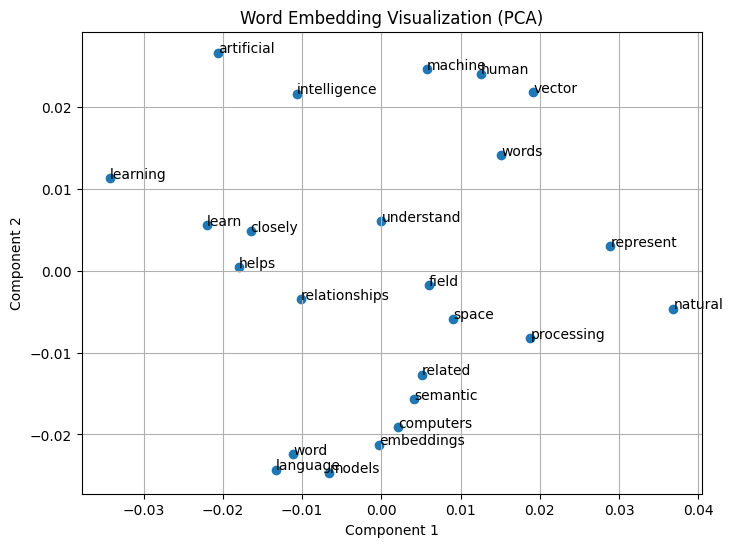

In [10]:
# ==============================
# Install dependencies (run once in Colab)
# ==============================
# !pip install gensim nltk scikit-learn matplotlib

# ==============================
# Imports
# ==============================
import nltk
import numpy as np
import matplotlib.pyplot as plt
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from gensim.models import Word2Vec
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

# ==============================
# Download NLTK resources (FIXED)
# ==============================
nltk.download('punkt', force=True)
nltk.download('punkt_tab', force=True)
nltk.download('stopwords', force=True)

# ==============================
# Sample Text Corpus
# ==============================
text_corpus = """
Natural language processing is a field of artificial intelligence.
Machine learning helps computers understand human language.
Word embeddings represent words in vector space.
Artificial intelligence and machine learning are closely related.
Language models learn semantic relationships between words.
"""

# ==============================
# Preprocessing
# ==============================
stop_words = set(stopwords.words('english'))

sentences = []
for sentence in text_corpus.split('.'):
    tokens = word_tokenize(sentence.lower())

    # Keep only alphabets and remove stopwords
    tokens = [word for word in tokens if word.isalpha() and word not in stop_words]

    if tokens:
        sentences.append(tokens)

print("Tokenized Sentences:")
print(sentences)

# ==============================
# Train Word2Vec Model
# ==============================
model = Word2Vec(
    sentences,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4,
    sg=1,          # Skip-gram
    epochs=100
)

# ==============================
# Word Vector Representation
# ==============================
word = "language"

if word in model.wv:
    vector = model.wv[word]
    print(f"\nVector for '{word}' (first 10 values):\n", vector[:10])
else:
    print(f"\nWord '{word}' not found in vocabulary")

# ==============================
# Similar Words
# ==============================
print("\nWords similar to 'intelligence':")

if "intelligence" in model.wv:
    similar_words = model.wv.most_similar("intelligence")
    for w, score in similar_words:
        print(f"{w} -> {score:.4f}")
else:
    print("Word not in vocabulary")

# ==============================
# Cosine Similarity
# ==============================
if "artificial" in model.wv and "machine" in model.wv:
    vec1 = model.wv["artificial"]
    vec2 = model.wv["machine"]

    similarity = cosine_similarity([vec1], [vec2])
    print(f"\nCosine similarity (artificial vs machine): {similarity[0][0]:.4f}")
else:
    print("Words not found for similarity calculation")

# ==============================
# PCA Visualization (2D)
# ==============================
words = list(model.wv.index_to_key)
word_vectors = model.wv[words]

pca = PCA(n_components=2)
result = pca.fit_transform(word_vectors)

plt.figure(figsize=(8, 6))
plt.scatter(result[:, 0], result[:, 1])

# Annotate words
for i, w in enumerate(words):
    plt.annotate(w, xy=(result[i, 0], result[i, 1]))

plt.title("Word Embedding Visualization (PCA)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.grid()

plt.show()